# DRIPS blob finder — interactive run

Runs the actual `DRIPSSeeder` class cell-by-cell instead of via `.run()`, so each stage's output (blobs, groups, filtered sources) is inspectable before moving on. Plots render inline in addition to being saved to disk.


In [187]:
%matplotlib inline
import sys, os

# EDIT: path to the directory containing pipeline_helpers.py
sys.path.append('./')


## DRIPSSeeder (verbatim)

Unmodified copy of the production class, so this notebook stays a faithful harness rather than a fork. If you patch the class file on disk, re-paste the updated source here to keep them in sync.


In [ ]:
import os
import re
import sys
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
%matplotlib inline
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
import astropy.wcs.utils as astropy_utils

from scipy.ndimage import gaussian_filter
from skimage.filters import difference_of_gaussians
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import yaml


from pipeline_helpers import (
    load_hawc_data,
    make_plots,
    soft_floor,
    estimate_background_sigma,
    # run_ps,
    run_ext,
    # blob_filter_intensity,
    combine_blobs,
    # remove_overlapping_blobs,
    compute_bright_frac,
    calculate_separation,
    circle_overlap,
    deduplicate_ps_group,
    ultimet,
    find_peak,
    threeML_model_from_sources,
)
from skimage.feature import blob_dog


def blob_filter_intensity(blobs, image, min_intensity, wcs, npix):
    filtered_blobs = []
    filtered_coords = []
    filtered_radius = []

    image = np.asarray(image)
    nrows, ncols = image.shape

    for y, x, r in blobs:

        # Extract local patch
        y_min = int(max(y - r, 0))
        y_max = int(min(y + r, nrows))
        x_min = int(max(x - r, 0))
        x_max = int(min(x + r, ncols))

        patch = image[y_min:y_max, x_min:x_max]
        yy, xx = np.ogrid[y_min:y_max, x_min:x_max]
        dist = np.sqrt((yy - y)**2 + (xx - x)**2)
        mask = dist <= (0.9 * r)
        inside_pixels = patch[mask]
        if np.any(inside_pixels > min_intensity):

            coord = astropy_utils.pixel_to_skycoord(x, y, wcs=wcs).icrs

            filtered_blobs.append((y, x, r))
            filtered_coords.append(coord)
            filtered_radius.append(r * npix)

            print(
                f"Blob accepted: max pixel={inside_pixels.max():.3f}, "
                f"Coords ({coord.ra:.2f}, {coord.dec:.2f}), "
                f"Radius={r:.2f}, Angular Radius={r*npix:.3f}"
            )

    return filtered_blobs, filtered_coords, filtered_radius

def run_ps(dog_final, pixel_size, threshold_val, border_pixels):
    return blob_dog(dog_final,
                    min_sigma=0.1 / pixel_size, max_sigma=0.6 / pixel_size,
                    threshold=threshold_val, exclude_border=border_pixels, overlap=0.7)

def run_ext(extmap, pixel_size, threshold_val, border_pixels):
    return blob_dog(extmap,
                    min_sigma=0.5 / pixel_size, max_sigma=1 / pixel_size,
                    threshold=threshold_val, exclude_border=border_pixels, overlap=0.7)


def remove_overlapping_blobs(blobs, coords, radii, array, overlap_threshold=0.5):
    """
    Merge overlapping blobs into a single TS-weighted blob per group,
    rather than keeping one and discarding the rest.

    Parameters:
    -----------
    blobs : array of shape (n_blobs, 3)
        Each row: [y, x, radius]
    coords : list of SkyCoord objects
        Corresponding sky coordinates
    radii : list of float
        Corresponding radii values
    array : 2D np.ndarray
        Significance map used to look up TS at each blob center (y, x)
    overlap_threshold : float
        Overlap metric threshold above which blobs are grouped as the same source

    Returns:
    --------
    filtered_blobs, filtered_coords, filtered_radii : merged blobs (one per group)
    removed_blobs, removed_coords, removed_radii : original blobs that were merged away
        (kept for diagnostics/plotting — these are the pre-merge inputs, minus the
        one nominal "representative" per group, i.e. everything that got absorbed)
    """
    if len(blobs) == 0:
        return blobs, coords, radii, np.empty((0, 3)), [], []

    n = len(blobs)
    ts_vals = np.array([
        array[int(round(b[0])), int(round(b[1]))] for b in blobs
    ])

    # --- union-find over the overlap graph ---
    parent = list(range(n))

    def find(i):
        while parent[i] != i:
            parent[i] = parent[parent[i]]
            i = parent[i]
        return i

    def union(i, j):
        ri, rj = find(i), find(j)
        if ri != rj:
            parent[ri] = rj

    for i in range(n):
        for j in range(i + 1, n):
            dy = blobs[i, 0] - blobs[j, 0]
            dx = blobs[i, 1] - blobs[j, 1]
            distance = np.sqrt(dy**2 + dx**2)
            smaller_r = min(blobs[i, 2], blobs[j, 2])
            if smaller_r <= 0:
                continue
            overlap = (blobs[i, 2] + blobs[j, 2] - distance) / smaller_r
            if overlap > overlap_threshold:
                union(i, j)

    groups = {}
    for i in range(n):
        root = find(i)
        groups.setdefault(root, []).append(i)

    filtered_blobs, filtered_coords, filtered_radii = [], [], []
    removed_blobs, removed_coords, removed_radii = [], [], []

    for members in groups.values():
        idx = np.array(members)
        w = ts_vals[idx]

        if np.all(w <= 0) or np.sum(np.abs(w)) == 0:
            # degenerate case: no positive TS to weight by, fall back to
            # simple mean so a divide-by-zero can't happen
            w = np.ones_like(w)

        w_norm = w / np.sum(w)

        y_avg = np.sum(w_norm * blobs[idx, 0])
        x_avg = np.sum(w_norm * blobs[idx, 1])
        r_avg = np.sum(w_norm * blobs[idx, 2])

        ra_avg  = np.sum(w_norm * np.array([coords[i].icrs.ra.deg  for i in idx]))
        dec_avg = np.sum(w_norm * np.array([coords[i].icrs.dec.deg for i in idx]))
        coord_avg = SkyCoord(ra=ra_avg * u.degree, dec=dec_avg * u.degree, frame='icrs')

        radius_avg = np.sum(w_norm * np.array([radii[i] for i in idx]))

        filtered_blobs.append([y_avg, x_avg, r_avg])
        filtered_coords.append(coord_avg)
        filtered_radii.append(radius_avg)

        if len(members) > 1:
            for i in idx:
                removed_blobs.append(blobs[i])
                removed_coords.append(coords[i])
                removed_radii.append(radii[i])

    filtered_blobs = np.array(filtered_blobs) if filtered_blobs else np.empty((0, 3))
    removed_blobs  = np.array(removed_blobs)  if removed_blobs  else np.empty((0, 3))

    return filtered_blobs, filtered_coords, filtered_radii, removed_blobs, removed_coords, removed_radii
class DRIPSSeeder():
    """A class to manage the seeding of Drips."""
    def __init__(
        self,
        config: object,
        logger: object,
        directory_manager: object,
        step_path,
        sig_map_path_override: Optional[str] = None,
    ):
        self.config = config
        self.logger = logger
        self.directory_manager = directory_manager
        self.step_path = step_path

        if sig_map_path_override is not None:
            self.initialmap = sig_map_path_override
            logger.info(f"Using overridden significance map: {self.initialmap}")
        else:
            try:
                self.initialmap = self.config.get('coordinates.sig_map_path')
                if self.initialmap is None:
                    raise ValueError("sig_map_path is not set in the config")
                logger.info(f"Using significance map from config: {self.initialmap}")
            except Exception as e:
                self.initialmap = directory_manager.get_datamap_dir() / 'significance_map.fits'
                logger.info(f"Using significance map created: {self.initialmap}")

        self.coord_sys = self.config.get('coordinates.coord_sys')
        if self.coord_sys not in ['C', 'G']:
            raise ValueError(f"Invalid coordinate system '{self.coord_sys}' in config. Must be 'C' or 'G'.")
        if self.coord_sys == 'C':
            if self.config.get('coordinates.ra') is not None:
                self.ra = float(self.config.get('coordinates.ra'))
                self.dec = float(self.config.get('coordinates.dec'))
                central_coord = SkyCoord(ra=self.ra*u.degree, dec=self.dec*u.degree, frame='icrs')
                self.l = central_coord.galactic.l.deg
                self.b = central_coord.galactic.b.deg
            else:
                raise ValueError("Coordinates not provided.")
        else:
            if self.config.get('coordinates.l') is not None or self.config.get('coordinates.b') is not None:
                self.l = float(self.config.get('coordinates.l'))
                self.b = float(self.config.get('coordinates.b'))
                
            else:
                raise ValueError("Coordinates not provided.")
        self.seed_coord_sys = 'G'
        self.x_length = self.config.get('coordinates.roi_x', 1.0)
        self.y_length = self.config.get('coordinates.roi_y', 1.0)
        if self.x_length < 2:
            self.x_length += 3
        if self.y_length < 2:
            self.y_length += 3
        
        self.out_dir = step_path
        self.logger.info(f"Using galactic coordinates from config: (l={self.l}, b={self.b})")
        self.logger.info(f"ROI size: {self.x_length}° x {self.y_length}°")
        self.logger.info(f"Output directory for seeding: {self.out_dir}")

        self.use_dbe = self.config.get('diffuse.use_diffuse_background')
        if self.use_dbe is True:
            self.dbe_template = self.config.get('diffuse.diffuse_template_path')
        else:
            self.dbe_template = None
        self.logger.info(f"Running seed model search in {self.out_dir}")
        os.makedirs(self.out_dir, exist_ok=True)
        self.SIG_THRESHOLD = 5.0
        self.SMEAR_RADII = [0.25, 0.3, 0.4, 0.5]

    def load_hawc_data(self) -> None:
        """Load significance map and set array, wcs, dims, pixel size."""
        self.logger.info(f"Loading HAWC data from {self.initialmap}")
        self.array, self.header, self.wcs, self.xnum, self.ynum, self.pixel_size = load_hawc_data( self.initialmap, self.l, self.b, self.x_length, self.y_length, self.seed_coord_sys )

    def plot_maps(
        self,
        array: np.ndarray,
        wcs: WCS,
        pixel_size: float,
        coord_sys: str,
        max_signif: float,
        vmin: float,
        vmax: float,
        threshold: float,
        contour: bool = True,
        title: str = 'Sky Map',
        hotspots: list = None,
        blobs: dict = None,
        labels: list = None,
    ) -> None:
        """Render a significance/normalised map to {out_dir}/{title}.png."""
        fig, _ = make_plots(
                array, wcs, pixel_size, coordsys=coord_sys,
                threshold=threshold, vmin=vmin, vmax=vmax, contour=contour, blobs=blobs,
                title=f'{title} (Max Sig {max_signif})',
                hotspots=hotspots, save_dir=None, pdf=False,
                cmap='ult', figsize=(10, 6),
                labels=labels,
            )
        plt.savefig(f"{self.out_dir}/{title}.png", dpi=300)
        plt.close()

    def normalise_image(self, array: np.ndarray) -> None:
        """Soft-floor and min-max normalise the significance map to [0,1]."""
        if np.max(self.array) < self.SIG_THRESHOLD:
            self.logger(f"    Below threshold ({np.max(self.array):.2f} < {self.SIG_THRESHOLD}sigma) — skipping.")
            fig_blank, ax_blank = plt.subplots(figsize=(8.5, 4))
            ax_blank.axis('off')
            ax_blank.text(0.5, 0.5,
                            f"No data > {self.SIG_THRESHOLD}sigma in file\n"
                            f"(Max = {np.max(self.array):.2f}sigma)",
                            fontsize=12, ha='center', va='center')
            raise ValueError(f"No excess found in the region")
        else:
            print(f"  Max significance {np.max(self.array):.2f}sigma exceeds threshold {self.SIG_THRESHOLD}sigma — proceeding with analysis.")
        if np.min(self.array) < -5:
            print("  Image softly floored to -5sigma")
            self.array = soft_floor(self.array, floor_min=-6, scale=1.0)

        self.norm_image = (self.array - self.array.min()) / (self.array.max() - self.array.min())
        
    def blob_detection(self, array: np.ndarray) -> None:
        """Run DoG blob detection across SMEAR_RADII; set final PS/EXT blobs."""
        self.all_ps_blobs,  self.all_ps_coords,  self.all_ps_radii  = [], [], []
        self.all_ext_blobs, self.all_ext_coords, self.all_ext_radii = [], [], []
        pbar = tqdm(self.SMEAR_RADII, desc='Processing Radii', leave=False)
        for radius in pbar:
            pbar.set_description(f"Processing radius {radius:.2f}°")
            smear_radius=radius
            pixel_smear = smear_radius/self.pixel_size

            print(f"Number of pixels corresponding to {smear_radius:.2f} smear radius = {pixel_smear:.2f}")

            dog_image = difference_of_gaussians(self.norm_image, 1, pixel_smear)
            sigma_resid = estimate_background_sigma(dog_image)
            print("Estimated background RMS:", sigma_resid)

            dog_final = np.where(dog_image > 2 * sigma_resid, dog_image, 0)
            dog_norm = (dog_final-np.min(dog_final))/(np.max(dog_final)-np.min(dog_final))
            extmap=gaussian_filter(self.norm_image-dog_norm, sigma=0.3/self.pixel_size)
            threshold_val = sigma_resid

            with ThreadPoolExecutor(max_workers=2) as ex:
                f_ps  = ex.submit(run_ps,  dog_final, self.pixel_size, threshold_val, self.border_pixels)
                f_ext = ex.submit(run_ext, extmap,    self.pixel_size, threshold_val, self.border_pixels)
                # f_ext = f_ps

            ps_blobs, ext_blobs = f_ps.result(), f_ext.result()

            print(f"Raw blobs — point source: {len(ps_blobs)}, extended: {len(ext_blobs)}")

            fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

            axes[0].imshow(dog_final, origin='lower', cmap='viridis')
            axes[0].set_title(f'dog_final (smear={smear_radius:.2f}°) — PS blobs (n={len(ps_blobs)})')
            for b in ps_blobs:
                y, x, r = b
                axes[0].add_patch(plt.Circle((x, y), r, fill=False, edgecolor='tomato', linewidth=1.5))
            for b in ext_blobs:
                y, x, r = b
                axes[0].add_patch(plt.Circle((x, y), r, fill=False, edgecolor='steelblue', linewidth=1.5))

            axes[1].imshow(extmap, origin='lower', cmap='viridis')
            axes[1].set_title(f'extmap (smear={smear_radius:.2f}°) — EXT blobs (n={len(ext_blobs)})')
            for b in ps_blobs:
                y, x, r = b
                axes[1].add_patch(plt.Circle((x, y), r, fill=False, edgecolor='tomato', linewidth=1.5))
            for b in ext_blobs:
                y, x, r = b
                axes[1].add_patch(plt.Circle((x, y), r, fill=False, edgecolor='steelblue', linewidth=1.5))

            plt.tight_layout()
            plt.savefig(f"{self.out_dir}/DogExtMap_Blobs_smear{smear_radius:.2f}.png", dpi=200)
            plt.show()

            ps_filt, ps_coords, ps_radii = (
                    blob_filter_intensity(ps_blobs,  self.array, 1, self.wcs, self.pixel_size)
                    if len(ps_blobs)  > 0 else (np.empty((0,3)), [], [])
                )
            ext_filt, ext_coords, ext_radii = (
                blob_filter_intensity(ext_blobs, self.array, 1, self.wcs, self.pixel_size)
                if len(ext_blobs) > 0 else (np.empty((0,3)), [], [])
            )

            print(f"Sources after 5$\\sigma$ filtering: {len(ps_filt) + len(ext_filt)}")

            if len(ps_filt)  > 0:
                self.all_ps_blobs.append(ps_filt);   self.all_ps_coords.append(ps_coords);   self.all_ps_radii.append(ps_radii)
            if len(ext_filt) > 0:
                self.all_ext_blobs.append(ext_filt); self.all_ext_coords.append(ext_coords); self.all_ext_radii.append(ext_radii)


        combined_ps_blobs,  combined_ps_coords,  combined_ps_radii  = combine_blobs(self.all_ps_blobs,  self.all_ps_coords,  self.all_ps_radii)
        combined_ext_blobs, combined_ext_coords, combined_ext_radii = combine_blobs(self.all_ext_blobs, self.all_ext_coords, self.all_ext_radii)

        final_ps_blobs,  _,  _,  *_ = remove_overlapping_blobs(combined_ps_blobs,  combined_ps_coords,  combined_ps_radii, self.array)
        final_ext_blobs, _, _, *_ = remove_overlapping_blobs(combined_ext_blobs, combined_ext_coords, combined_ext_radii, self.array)

        self.final_ps_blobs,  self.final_ps_coords,  self.final_ps_radii  = blob_filter_intensity(final_ps_blobs,  self.array, 5, self.wcs, self.pixel_size)
        self.final_ext_blobs, self.final_ext_coords, self.final_ext_radii = blob_filter_intensity(final_ext_blobs, self.array, 5, self.wcs, self.pixel_size)

        print(f"  PS  after all cuts: {len(self.final_ps_blobs):>4}")
        print(f"  EXT after all cuts: {len(self.final_ext_blobs):>4}")

    def group_blobs(self) -> None:
        """Group overlapping PS blobs under their parent EXT blob."""
        self.groups = []
        matched_ps = set()

        for lb in self.final_ext_blobs:
            ly, lx, lr = lb
            matched = []
            for i, sb in enumerate(self.final_ps_blobs):
                sy, sx, sr = sb
                frac = self.overlap_fraction(ly, lx, lr, sy, sx, sr)
                if frac > 0.1:
                    matched.append((sb, frac))
                    matched_ps.add(i)
            self.groups.append((lb, matched))

        for i, sb in enumerate(self.final_ps_blobs):
            if i not in matched_ps:
                self.groups.append((None, [(sb, 0.0)]))

    def blob_filters(self) -> Tuple[list, list, list, list]:
        """Classify grouped blobs into kept/removed PS and EXT sources."""
        self.ext_removed_group, self.ps_removed_group, self.ext_filtered_group, self.ps_filtered_group = [], [], [], []
        for lb, sbs in self.groups:
            tag_ps     = 0
            tag_ex     = 0
            ps_flagged = []
            if lb is None:
                for sb, _ in sbs:
                    self.ps_filtered_group.append(sb)
                continue

            ly, lx, lr = lb
            ly, lx     = int(ly), int(lx)

            bright_frac = compute_bright_frac(self.array, ly, lx, lr)
            print(f"Intensity Fraction of pixels greater than 5 sigma detection threshold = {100*bright_frac:.1f}%")
            if bright_frac < 0.5:
                if len(sbs) > 1:
                    print("Larger blob is artifact of blob detection on subtracted map")
                    tag_ex += 1
                    for sb, _ in sbs:
                        ps_flagged.append(sb)
            else:
                coord_lb   = astropy_utils.pixel_to_skycoord(lx, ly, wcs=self.wcs).galactic
                if len(sbs) == 0:
                    self.ext_filtered_group.append(lb)
                    continue
                print(f"Larger blob coord = {coord_lb.l.deg, coord_lb.b.deg}")
                if len(sbs) > 1:
                    lb_ts = float(self.array[ly, lx])
                    sbs_ts = [float(self.array[int(sb[0]), int(sb[1])]) for sb, _ in sbs]

                    print(f"  Found {len(sbs)} smaller blobs overlapping larger blob")
                    print(f"  LB TS={lb_ts:.2f}, SB TSs={[f'{t:.2f}' for t in sbs_ts]}")

                    # Split small blobs into brighter-than-LB and dimmer-than-LB
                    brighter_sbs = [(sb, ov) for (sb, ov), ts in zip(sbs, sbs_ts) if ts >= lb_ts]
                    dimmer_sbs   = [(sb, ov) for (sb, ov), ts in zip(sbs, sbs_ts) if ts <  lb_ts]

                    if len(brighter_sbs) == len(sbs):
                        # ALL small blobs brighter than LB -> remove LB, keep all SBs
                        self.ps_filtered_group.extend([sb for sb, _ in sbs])
                        self.ext_removed_group.append(lb)
                        print("  All SBs brighter than LB -> keeping all SBs, removing LB")
                        continue
                    else:
                        # Some SBs are dimmer: keep LB + any SBs brighter than LB, drop dimmer SBs
                        self.ext_filtered_group.append(lb)
                        self.ps_filtered_group.extend([sb for sb, _ in brighter_sbs])
                        self.ps_removed_group.extend([sb for sb, _ in dimmer_sbs])
                        print(f"  LB is brightest or mixed -> keeping LB + {len(brighter_sbs)} brighter SBs, "
                            f"removing {len(dimmer_sbs)} dimmer SBs")
                        continue
                print(f"  No smaller blobs overlapping larger blob — tagging as EXT")
                for sb, _ in sbs:
                    sy, sx, sr  = sb
                    sy, sx      = int(sy), int(sx)
                    coord_sb    = astropy_utils.pixel_to_skycoord(sx, sy, wcs=self.wcs).galactic
                    sep_deg     = calculate_separation(coord_lb, coord_sb)
                    ovl         = circle_overlap(coord_lb, lr, coord_sb, sr, self.pixel_size)
                    delta_ts    = float(self.array[ly, lx]) - float(self.array[sy, sx])

                    if sep_deg < 0.1:
                        tag_ex +=1
                        ps_flagged.append(sb)
                        print(f"  Very close PS blob at (x={sx}, y={sy}, r={sr:.2f} pixels) with sep={sep_deg:.3f}° — tagging as EXT")
                        continue
                    if ovl is None:
                        if sep_deg > 0.3:
                            tag_ps += 1
                            ps_flagged.append(sb)
                            print(f"  PS blob at (x={sx}, y={sy}, r={sr:.2f} pixels) with sep={sep_deg:.3f}° and no overlap — tagging as PS")
                        else:
                            if delta_ts < 5:
                                tag_ex+=1
                                ps_flagged.append(sb)
                                print(f"  PS blob at (x={sx}, y={sy}, r={sr:.2f} pixels) with sep={sep_deg:.3f}° and no overlap but low TS difference ({delta_ts:.1f}) — tagging as EXT")
                            else:
                                self.ps_removed_group.append(sb)
                                print(f"  PS blob at (x={sx}, y={sy}, r={sr:.2f} pixels) with sep={sep_deg:.3f}° and no overlap but high TS difference ({delta_ts:.1f}) — tagging as PS")
                    elif ovl == 1.0:
                        if sep_deg > 0.3 and delta_ts >= 9:
                            tag_ps += 1;  tag_ex += 1;  ps_flagged.append(sb)
                            print(f"  PS blob at (x={sx}, y={sy}, r={sr:.2f} pixels) with sep={sep_deg:.3f}° and no overlap but high TS difference ({delta_ts:.1f}) — tagging as PS")
                        elif delta_ts >= 9:
                            tag_ps += 1;  ps_flagged.append(sb)
                            print(f"  PS blob at (x={sx}, y={sy}, r={sr:.2f} pixels) with sep={sep_deg:.3f}° and no overlap but high TS difference ({delta_ts:.1f}) — tagging as PS")
                        else:
                            self.ps_removed_group.append(sb)
                            print(f"  PS blob at (x={sx}, y={sy}, r={sr:.2f} pixels) with sep={sep_deg:.3f}° and no overlap but high TS difference ({delta_ts:.1f}) — tagging as PS")

            if tag_ex > 0:
                self.ext_removed_group.append(lb)
            else:
                self.ext_filtered_group.append(lb)
            print(f"PS flagged: {len(ps_flagged)}")
            self.ps_filtered_group.extend(ps_flagged)

        print(f"  Kept   — PS: {len(self.ps_filtered_group)}  EXT: {len(self.ext_filtered_group)}")
        print(f"  Removed— PS: {len(self.ps_removed_group)}  EXT: {len(self.ext_removed_group)}")

        self.ps_filtered_group, ps_dedup_removed = deduplicate_ps_group(
        self.ps_filtered_group, self.wcs, sep_threshold_deg=0.3
        )
        self.ps_removed_group.extend(ps_dedup_removed)

        print(f"Final — PS kept: {len(self.ps_filtered_group)}  EXT kept: {len(self.ext_filtered_group)}")
        print(f"        PS removed: {len(self.ps_removed_group)}  EXT removed: {len(self.ext_removed_group)}")
        return self.ps_filtered_group, self.ext_filtered_group, self.ps_removed_group, self.ext_removed_group

    def overlap_fraction(self, ly, lx, lr, sy, sx, sr) -> float:
        """Fraction of the smaller blob's area that overlaps with the larger blob."""
        dist = np.sqrt((sy - ly)**2 + (sx - lx)**2)
        if dist >= lr + sr:
            return 0.0
        if dist + sr <= lr:
            return 1.0

        r, R = sr, lr   # small, large radii
        d    = dist

        alpha = np.arccos((d**2 + r**2 - R**2) / (2 * d * r))  # half-angle at small circle center
        beta  = np.arccos((d**2 + R**2 - r**2) / (2 * d * R))  # half-angle at large circle center

        intersection = r**2 * alpha + R**2 * beta - 0.1 * (r**2 * np.sin(2*alpha) + R**2 * np.sin(2*beta))
        small_area   = np.pi * r**2

        return intersection / small_area

    def plot_filtering_results(self, title: str = 'FilteredBlobs') -> None:
        """Overlay kept PS/EXT blobs on the significance map and save PNG."""
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection=self.wcs)
        ult = ultimet(-5, 9, 4)
        im = ax.imshow(self.array, cmap=ult, vmin=-5, vmax=9)
        plt.colorbar(im, ax=ax, label=r'Significance($\sigma$)', fraction=0.046, pad=0.04)
        for lb in self.ext_filtered_group:
            ly, lx, lr = lb
            ly, lx = int(ly), int(lx)
            center_intensity_lb = self.array[ly, lx]

            circle_l = plt.Circle((lx, ly), lr, fill=False, edgecolor='black', linewidth=2.0, linestyle='--')
            ax.add_patch(circle_l)
            ax.scatter(lx, ly, s=80, c='black', marker='*', zorder=5)
            ax.text(lx, ly + lr + 10, f'TS={center_intensity_lb:.1f}',
                    color='black', fontsize=10, ha='center')


        for sb in self.ps_filtered_group:
            try:
                sy, sx, sr = sb
            except:
                sy, sx, sr = sb[0][0]
            sy, sx = int(sy), int(sx)
            center_intensity_sb = self.array[sy, sx]
            circle_s = plt.Circle((sx, sy), sr, fill=False, edgecolor='white', linewidth=2, linestyle='-')
            ax.add_patch(circle_s)
            ax.scatter(sx, sy, s=60, c='white', marker='*', zorder=5)
            ax.text(sx + sr + 20, sy + sr + 10, f'TS={center_intensity_sb:.1f}',
                    color='white', fontsize=10, ha='center')

        legend_handles = [
            Line2D([0], [0], color='black',  linewidth=2,   linestyle='--', label='larger blob (kept)'),
            Line2D([0], [0], color='cyan',   linewidth=1.5, linestyle='--', label='smaller blob (grouped)'),
            Line2D([0], [0], color='blue',   linewidth=1.2, linestyle=':',  label='smaller blob (ps pool)'),
        ]

        ax.set_xlim(0, self.xnum)
        ax.set_ylim(0, self.ynum)
        ax.legend(handles=legend_handles, fontsize=8, loc='upper right')
        ax.set_title('All filtered blobs — larger (white), grouped smaller (cyan), ps pool (blue)', fontsize=9)
        ax.set_xlabel('X (px)')
        ax.set_ylabel('Y (px)')
        plt.tight_layout()
        plt.savefig(f"{self.out_dir}/{title}.png", dpi=300)
        plt.close()

    def radius_to_sigma(self, R, fraction=0.6827):
        """Convert a blob circle radius to a Gaussian sigma for a containment fraction."""
        return R / np.sqrt(2 * np.log(1 / (1 - fraction)))

    def convert_to_coord(self, input_blobs, wcs, npix):
        """Convert pixel blobs to (blob, SkyCoord, angular-radius) triples."""
        blobs = []
        coords = []
        radius = []

        for y, x, r in input_blobs:
            coord = astropy_utils.pixel_to_skycoord(x, y, wcs=wcs).icrs

            blobs.append((y, x, r))
            coords.append(coord)
            radius.append(r * npix)
            print(f"Converting blob at (x={x}, y={y}, r={r:.2f} pixels) to coord (RA={coord.ra.deg:.3f}°, Dec={coord.dec.deg:.3f}°) with radius {r * npix:.2f}°")
        return blobs, coords, radius

    def save_model(self) -> None:
        """Convert blobs to coordinates and save results to YAML file, filtering to original ROI."""
        _, ext_coords, ext_radius = self.convert_to_coord(self.ext_filtered_group, self.wcs, self.pixel_size)
        _, ps_coords, ps_radius = self.convert_to_coord(self.ps_filtered_group, self.wcs, self.pixel_size)

        total_coords = ps_coords + ext_coords
        total_coords_ra = [i.ra.value for i in ps_coords] + [i.ra.value for i in ext_coords]
        total_coords_dec = [i.dec.value for i in ps_coords] + [i.dec.value for i in ext_coords]
        total_radius = ps_radius + ext_radius

        names = [f'Drip{i}' for i in range(len(total_coords))]

        # Create DataFrame with all sources
        df_all = pd.DataFrame({
            'Name': names,
            'ra': total_coords_ra,
            'dec': total_coords_dec,
            'ext': total_radius,
            'Circle Radius': total_radius,
            'Sigma Radius': [self.radius_to_sigma(R) for R in total_radius]
        })

        # Get original ROI (without the +3 extension)
        original_roi_x = self.config.get('coordinates.roi_x', 1.0)
        original_roi_y = self.config.get('coordinates.roi_y', 1.0)

        # Filter sources within original ROI bounds
        filtered_rows = []
        for _, row in df_all.iterrows():
            coord = SkyCoord(ra=row['ra']*u.degree, dec=row['dec']*u.degree, frame='icrs').galactic
            l_diff = abs(coord.l.deg - self.l)
            b_diff = abs(coord.b.deg - self.b)

            # Keep if within original ROI
            if l_diff <= original_roi_x and b_diff <= original_roi_y:
                filtered_rows.append(row)

        # Create filtered DataFrame
        if filtered_rows:
            self.filtered_df = pd.DataFrame(filtered_rows).reset_index(drop=True)
            self.filtered_df['Name'] = [f'Drip{i}' for i in range(len(self.filtered_df))]
        else:
            self.filtered_df = pd.DataFrame(columns=['Name', 'ra', 'dec', 'ext', 'Circle Radius', 'Sigma Radius'])

        # Save to YAML
        if len(self.filtered_df) > 0:
            sources_data = {
                'roi_info': {
                    'center_l': float(self.l),
                    'center_b': float(self.b),
                    'roi_x': float(original_roi_x),
                    'roi_y': float(original_roi_y),
                    'total_sources_detected': len(df_all),
                    'sources_in_roi': len(self.filtered_df)
                },
                'sources': [
                    {
                        'name': row['Name'],
                        'ra': float(row['ra']),
                        'dec': float(row['dec']),
                        'ext': float(row['ext']),
                        'circle_radius_deg': float(row['Circle Radius']),
                        'sigma_radius': float(row['Sigma Radius'])
                    }
                    for _, row in self.filtered_df.iterrows()
                ]
            }
            self.logger.info(f"Found {len(df_all)} sources, {len(self.filtered_df)} within original ROI")
        else:
            sources_data = {
                'roi_info': {
                    'center_l': float(self.l),
                    'center_b': float(self.b),
                    'roi_x': float(original_roi_x),
                    'roi_y': float(original_roi_y),
                    'total_sources_detected': len(df_all),
                    'sources_in_roi': 0
                },
                'sources': [],
                'note': 'No sources found within original ROI'
            }
            self.logger.info(f"Found {len(df_all)} sources, but none within original ROI")

        with open(f"{self.out_dir}/filtered_sources.yaml", 'w') as f:
            yaml.dump(sources_data, f, default_flow_style=False, sort_keys=False)

        self.logger.info(f"Results saved to: {self.out_dir}/filtered_sources.yaml")

        self.logger.info(f"Results saved to: {self.out_dir}/filtered_sources.yaml")

    def save_model_to_file(self, sources_dict, filtered_df, output_path="mymodel.model",
                       hermes_present=None, hermes_path=None) -> None:
        """
        Saves a threeML Model to a .model file matching the BEGINSOURCE/ENDSOURCE format.

        Parameters
        ----------
        model          : the threeML Model object
        sources_dict   : the `sources` dict you built (after removing spectrum keys)
        filtered_df    : your filtered DataFrame
        output_path    : path to write the .model file
        hermes_present : if True, prepend a URM/Hermes extended source block
        hermes_path    : path to the Hermes FITS file (required if hermes_present=True)
        """
        lines = []
        if hermes_present:
            if hermes_path is None:
                raise ValueError("hermes_path must be provided when hermes_present=True")

            lines += [
                "import astromodels",
                "##################################BEGINSOURCE##################################",
                'source_name = "URM"',
                "",
                "spectrum1 = threeML.Powerlaw()",
                f'shape1 = astromodels.Hermes(fits_file="{hermes_path}", ihdu=0)',
                "",
                "URM = threeML.ExtendedSource(source_name, spatial_shape=shape1, spectral_shape=spectrum1)",
                "",
                "fluxUnit = 1. / (threeML.u.TeV * threeML.u.cm ** 2 * threeML.u.s)",
                "",
                "shape1.N = 1",
                "shape1.N.fix = False",
                "shape1.N.bounds = (0.01, 100)",
                "",
                "spectrum1.K = 1",
                "spectrum1.K.fix = True",
                "",
                "spectrum1.index = 0",
                "spectrum1.index.fix = True",
                "###################################ENDSOURCE###################################",
                "",
            ]

        source_keys = sorted(sources_dict.keys(), key=lambda k: int(k.replace("source", "")))

        for key in source_keys:
            i = int(key.replace("source", ""))
            src       = sources_dict[key]
            src_name  = src.name
            is_extended = hasattr(src, 'spatial_shape')
            ra_val    = filtered_df['ra'].iloc[i]
            dec_val   = filtered_df['dec'].iloc[i]
            
            lines.append("##################################BEGINSOURCE##################################")
            lines.append(f'source_name = "{src_name}"')

            if not is_extended:
                sp = src.spectrum.main.shape

                lines += [
                    f"source_ra  = {ra_val}",
                    f"source_dec = {dec_val}",
                    "",
                    "spectrum = threeML.Powerlaw()",
                    f"{key} = threeML.PointSource(source_name, ra=source_ra, dec=source_dec, spectral_shape=spectrum)",
                    "fluxUnit = 1. / (threeML.u.keV * threeML.u.cm ** 2 * threeML.u.s)",
                    "",
                    f"spectrum.K = {sp.K.value:.3e} * fluxUnit",
                    "spectrum.K.fix = False",
                    "spectrum.K.bounds = (1e-26 * fluxUnit, 1e-20 * fluxUnit)",
                    "",
                    f"spectrum.piv = {10} * threeML.u.TeV",
                    "spectrum.piv.fix = True",
                    "",
                    f"spectrum.index = {sp.index.value}",
                    "spectrum.index.fix = False",
                    "spectrum.index.bounds = (-3., -1.)",
                    "",
                    f"{key}.position.ra.free = True",
                    f"{key}.position.ra.bounds = (({ra_val} - 1.0), ({ra_val} + 1.0)) * threeML.u.degree",
                    f"{key}.position.dec.free = True",
                    f"{key}.position.dec.bounds = (({dec_val} - 1.0), ({dec_val} + 1.0)) * threeML.u.degree",
                ]
            else:
                sp    = src.spectrum.main.shape
                morph = src.spatial_shape

                lines += [
                    "",
                    "spectrum = threeML.Powerlaw()",
                    "shape = threeML.Gaussian_on_sphere()",
                    f"{key} = threeML.ExtendedSource(source_name, spatial_shape=shape, spectral_shape=spectrum)",
                    "fluxUnit = 1. / (threeML.u.keV * threeML.u.cm ** 2 * threeML.u.s)",
                    "",
                    f"shape.lon0 = {morph.lon0.value} * threeML.u.degree",
                    "shape.lon0.fix = False",
                    f"shape.lon0.bounds = (({morph.lon0.value} - 1.0) * threeML.u.degree, ({morph.lon0.value} + 1.0) * threeML.u.degree)",
                    "",
                    f"shape.lat0 = {morph.lat0.value} * threeML.u.degree",
                    "shape.lat0.fix = False",
                    f"shape.lat0.bounds = (({morph.lat0.value} - 1.0) * threeML.u.degree, ({morph.lat0.value} + 1.0) * threeML.u.degree)",
                    "",
                    f"shape.sigma = {morph.sigma.value}",
                    "shape.sigma.fix = False",
                    "shape.sigma.bounds = (0.01, 4.0)",
                    "",
                    f"spectrum.K = {sp.K.value:.3e} * fluxUnit",
                    "spectrum.K.fix = False",
                    "spectrum.K.bounds = (1e-26 * fluxUnit, 1e-20 * fluxUnit)",
                    "",
                    f"spectrum.piv = {10} * threeML.u.TeV",
                    "spectrum.piv.fix = True",
                    "",
                    f"spectrum.index = {sp.index.value}",
                    "spectrum.index.fix = False",
                    "spectrum.index.bounds = (-3., -1.)",
                ]

            lines.append("###################################ENDSOURCE###################################")
            lines.append("")


        all_vars = ("URM, " if hermes_present else "") + ", ".join(source_keys)
        lines.append(f"model = threeML.Model({all_vars})")
        lines.append("")

        with open(output_path, "w") as f:
            f.write("\n".join(lines))

        print(f"Model saved to: {output_path}")

    def run_blob_detection(self) -> None:
        """Load data, normalise, detect blobs, and group them."""
        self.load_hawc_data()
        self.border_pixels = int(0.5 / self.pixel_size)
        print(f"  Map shape  : {self.ynum} × {self.xnum}  |  pixel size: {self.pixel_size:.4f}°")
        print(f"  Sig range  : [{np.min(self.array):.2f}, {np.max(self.array):.2f}]")
        self.max_signif = find_peak(self.array, self.wcs)

        self.plot_maps(self.array, self.wcs, self.pixel_size, self.seed_coord_sys, self.max_signif, -5, 15, 5, contour=True, title='SkyImage', labels=['4hwc'])

        self.normalise_image(self.array)

        self.plot_maps(self.norm_image, self.wcs, self.pixel_size, self.seed_coord_sys, self.max_signif, 0, 1, 0.4, contour=False, title='NormalisedImage', labels=['4hwc'])

        self.blob_detection(self.norm_image)

        self.blobs_dict = {'psblobs': self.final_ps_blobs, 'extblobs': self.final_ext_blobs}

        self.plot_maps(self.array, self.wcs, self.pixel_size, self.seed_coord_sys, self.max_signif, -5, 15, 5, contour=True, title='SkyImage_Blobs', blobs=self.blobs_dict, labels=['4hwc'])

        self.group_blobs()

    def run_filtering(self) -> None:
        """Run blob classification/filtering step."""
        self.blob_filters()
        print(f"  Kept   — PS: {len(self.ps_filtered_group)}  EXT: {len(self.ext_filtered_group)}")
        print(f"  Removed— PS: {len(self.ps_removed_group)}  EXT: {len(self.ext_removed_group)}")

    def run_source_detection(self) -> None:
        """Full detection: blobs -> filtering -> plots -> seed YAML."""
        self.run_blob_detection()
        self.run_filtering()
        self.plot_filtering_results(title='FilteredBlobs_Labels')
        self.save_model()
        self.plot_maps(self.array, self.wcs, self.pixel_size, self.seed_coord_sys, self.max_signif, -5, 15, 5.05, contour=True, title='Source Seeds', hotspots=self.filtered_df, labels=['4haaawc'])

    def run(self) -> None:
        """Original SourceSeedDetector.run(): detection + threeML model file.

        Extracted verbatim; produces filtered_df, allmodel, sources, and the
        curModel.model file.
        """
        if 'curModel.model' in os.listdir(self.out_dir):
            self.logger.info(f"Found existing model file in {self.out_dir}, skipping seeding.")
            model_path = Path(self.out_dir) / 'curModel.model'
            return model_path
        self.run_blob_detection()
        self.run_filtering()
        self.plot_filtering_results(title='FilteredBlobs_Labels')
        self.save_model()
        self.plot_maps(self.array, self.wcs, self.pixel_size, self.seed_coord_sys, self.max_signif, -5, 15, 5.05, contour=True, title='Source Seeds', hotspots=self.filtered_df, labels=['4haaawc'])
        self.allmodel, self.sources = threeML_model_from_sources(self.filtered_df)
        self.save_model_to_file(
            self.sources, self.filtered_df,
            output_path        = f"{self.out_dir}/curModel.model",
            hermes_present     = self.use_dbe,
            hermes_path        = self.dbe_template,
        )
        model_path = Path(self.out_dir) / 'curModel.model'
        return model_path


## Optional: connectivity + saddle-height deblending

Not used by default below — `group_blobs()`/`blob_filters()` run as the class defines them. Kept here so you can swap it in for comparison (see the commented block in the classification cell).


In [202]:
import numpy as np
from scipy.ndimage import label as ndlabel, maximum_filter, find_objects


def _find_saddle(patch, mask, peak_a, peak_b, levels):
    """Highest level at which peak_a and peak_b are STILL in the same
    connected component (i.e. the saddle/pass height between them).
    `levels` must be sorted ascending; connectivity is monotonic in level
    (raising the level only removes pixels), so this is a clean bisection.
    """
    def connected(level):
        m = (patch >= level) & mask
        lab, _ = ndlabel(m, structure=np.ones((3, 3), dtype=int))
        la, lb = lab[peak_a], lab[peak_b]
        return la != 0 and la == lb

    lo, hi = 0, len(levels) - 1
    if not connected(levels[lo]):
        return levels[lo]                 # shouldn't happen given mask construction
    while lo < hi:
        mid = (lo + hi + 1) // 2
        if connected(levels[mid]):
            lo = mid
        else:
            hi = mid - 1
    return levels[lo]


def deblend_segment(patch, mask, threshold, min_dts=16.0, nlevels=48,
                    min_distance=3, candidate_peaks=None):
    """Deblend one connected component (already cropped to its bbox).

    patch, mask : 2D arrays, same shape, cropped to the segment's bounding box
    threshold   : the detection threshold used to build `mask` (lowest level)
    min_dts     : DeltaTS bar for keeping two peaks as separate sources
    nlevels     : levels sampled between threshold and the segment's max
    min_distance: half-window (px) for local-maximum finding — set near your
                  PSF scale so you're not chasing single-pixel noise peaks
    candidate_peaks : optional list of (y, x) in this patch's LOCAL coords —
                  e.g. your existing blob_dog PS/EXT detections, translated
                  into the segment's bbox. IMPORTANT: a compact source
                  embedded near a broad extended source's peak can dominate
                  the combined field so completely that the extended
                  source's own centre is a shoulder, not a local maximum —
                  raw-pixel local-max finding then sees only ONE peak and
                  there is nothing downstream (saddle search, photutils,
                  anything working from pixel values alone) can do about
                  it. That's what the matched-filter blob_dog front end is
                  for; pass its candidates here so they still get a saddle/
                  DeltaTS test even when they aren't local maxima of the
                  raw significance map.

    Returns a list of dicts: {peak: (y,x), peak_val, n_merged, dts_to_next}
    one per surviving source. n_merged > 1 flags a source that absorbed
    weaker nearby peaks.
    """
    local_max = (patch == maximum_filter(patch, size=2 * min_distance + 1)) & mask
    peaks = set(tuple(c) for c in np.argwhere(local_max))
    if candidate_peaks:
        for py, px in candidate_peaks:
            py, px = int(round(py)), int(round(px))
            if 0 <= py < patch.shape[0] and 0 <= px < patch.shape[1] and mask[py, px]:
                peaks.add((py, px))
    peaks = list(peaks)
    if len(peaks) <= 1:
        if peaks:
            py, px = peaks[0]
        else:
            py, px = np.unravel_index(np.argmax(np.where(mask, patch, -np.inf)),
                                      patch.shape)
        return [{'peak': (py, px), 'peak_val': float(patch[py, px]),
                 'n_merged': 1, 'dts_to_next': None}]

    peaks.sort(key=lambda p: -patch[p])            # brightest first
    vmax = float(patch[peaks[0]])
    if vmax <= threshold:
        vmax = threshold + 1e-6
    levels = np.linspace(threshold, vmax, nlevels)

    parent = list(range(len(peaks)))
    best_dts = [None] * len(peaks)                 # DeltaTS to whatever it merged with

    def find(i):
        while parent[i] != i:
            parent[i] = parent[parent[i]]
            i = parent[i]
        return i

    def union(i, j, dts):
        ri, rj = find(i), find(j)
        if ri != rj:
            parent[ri] = rj
        if best_dts[i] is None or dts < best_dts[i]:
            best_dts[i] = dts

    for i in range(len(peaks)):
        for j in range(i):
            if find(i) == find(j):
                continue
            s = _find_saddle(patch, mask, peaks[i], peaks[j], levels)
            dip = min(patch[peaks[i]], patch[peaks[j]]) - s
            dts = float(dip * dip) if dip > 0 else 0.0
            if dts < min_dts:
                union(i, j, dts)               # saddle too shallow -> same source

    groups = {}
    for i in range(len(peaks)):
        groups.setdefault(find(i), []).append(i)

    out = []
    for idxs in groups.values():
        best = min(idxs)                       # peaks sorted brightest-first
        py, px = peaks[best]
        dts_vals = [best_dts[i] for i in idxs if best_dts[i] is not None]
        out.append({'peak': (py, px), 'peak_val': float(patch[py, px]),
                    'n_merged': len(idxs),
                    'dts_to_next': min(dts_vals) if dts_vals else None})
    return out


def deblend_map(array, threshold=5.0, min_area=10, min_dts=16.0,
                nlevels=48, min_distance=3, pad=2, candidate_peaks=None):
    """Connected-component grouping + saddle-height deblending over the
    whole map. Replaces build_groups()+classify_groups().

    candidate_peaks : optional list of (y, x) in ABSOLUTE map coords — feed
        your existing blob_dog PS+EXT detections here. See deblend_segment's
        docstring for why this matters: a compact source embedded near a
        broad extended source's peak can be statistically real yet
        invisible to raw local-max finding.

    Returns a list of source dicts with absolute pixel coordinates:
      {y, x, peak_val, n_merged, dts_to_next, segment_id, segment_area}
    """
    seg = array > threshold
    lab, n = ndlabel(seg, structure=np.ones((3, 3), dtype=int))
    objs = find_objects(lab)

    cand_by_label = {}
    if candidate_peaks:
        for cy, cx in candidate_peaks:
            iy, ix = int(round(cy)), int(round(cx))
            if 0 <= iy < array.shape[0] and 0 <= ix < array.shape[1]:
                lbl = lab[iy, ix]
                if lbl:
                    cand_by_label.setdefault(lbl, []).append((cy, cx))

    sources = []
    for lbl in range(1, n + 1):
        sl = objs[lbl - 1]
        if sl is None:
            continue
        y0 = max(sl[0].start - pad, 0)
        x0 = max(sl[1].start - pad, 0)
        y1 = min(sl[0].stop + pad, array.shape[0])
        x1 = min(sl[1].stop + pad, array.shape[1])

        mask_full = lab[y0:y1, x0:x1] == lbl
        if mask_full.sum() < min_area:
            continue
        patch = array[y0:y1, x0:x1]

        local_cands = [(cy - y0, cx - x0) for cy, cx in cand_by_label.get(lbl, [])]
        peaks = deblend_segment(patch, mask_full, threshold, min_dts=min_dts,
                                nlevels=nlevels, min_distance=min_distance,
                                candidate_peaks=local_cands or None)
        for pk in peaks:
            py, px = pk['peak']
            sources.append({
                'y': y0 + py, 'x': x0 + px,
                'peak_val': pk['peak_val'], 'n_merged': pk['n_merged'],
                'dts_to_next': pk['dts_to_next'],
                'segment_id': lbl, 'segment_area': int(mask_full.sum()),
            })
    return sources


## Minimal config / logger / directory-manager

`DRIPSSeeder` expects your project's `Config`, `Logger`, and `DirectoryManager` classes. If you have them, import and use those instead of these stand-ins — swap the `cfg`/`logger`/`dirman` lines in the next cell.


In [203]:
class DictConfig:
    """Minimal stand-in for your project's Config: dotted-key .get()."""
    def __init__(self, d):
        self._d = d
    def get(self, key, default=None):
        v = self._d
        for part in key.split('.'):
            if isinstance(v, dict) and part in v:
                v = v[part]
            else:
                return default
        return v


class SimpleLogger:
    def info(self, msg):
        print(f"[INFO] {msg}")


class SimpleDirManager:
    def __init__(self, path):
        from pathlib import Path
        self.path = Path(path)
        self.path.mkdir(parents=True, exist_ok=True)
    def get_datamap_dir(self):
        return self.path


In [204]:
# ── EDIT ME ──────────────────────────────────────────────────────────────
SIG_MAP_PATH = '/Users/rishi/Documents/Analysis/Sources/AstroImageDetection-fitmodel/HAWC-ImageProcessing-3MLFit/hawc_analysis/GRS/DataMapDir/significance_map.fits'
COORD_SYS    = 'G'          # 'G' (l,b) or 'C' (ra,dec)
L, B         = 45.75, 0    # used if COORD_SYS == 'G'
RA, DEC      = None, None   # used if COORD_SYS == 'C'
ROI_X, ROI_Y = 2.75, 4.0     # degrees, half-width
USE_DIFFUSE_BACKGROUND = False
DIFFUSE_TEMPLATE_PATH  = None
OUT_DIR = './drips_interactive_output'
# ─────────────────────────────────────────────────────────────────────────

cfg_dict = {
    'coordinates': {
        'sig_map_path': SIG_MAP_PATH,
        'coord_sys': COORD_SYS,
        'l': L, 'b': B, 'ra': RA, 'dec': DEC,
        'roi_x': ROI_X, 'roi_y': ROI_Y,
    },
    'diffuse': {
        'use_diffuse_background': USE_DIFFUSE_BACKGROUND,
        'diffuse_template_path': DIFFUSE_TEMPLATE_PATH,
    },
}

cfg     = DictConfig(cfg_dict)          # or your project's real Config
logger  = SimpleLogger()                # or your project's real Logger
dirman  = SimpleDirManager(OUT_DIR)     # or your project's real DirectoryManager

seeder = DRIPSSeeder(cfg, logger, dirman, step_path=OUT_DIR)


[INFO] Using significance map from config: /Users/rishi/Documents/Analysis/Sources/AstroImageDetection-fitmodel/HAWC-ImageProcessing-3MLFit/hawc_analysis/GRS/DataMapDir/significance_map.fits
[INFO] Using galactic coordinates from config: (l=45.75, b=0.0)
[INFO] ROI size: 2.75° x 4.0°
[INFO] Output directory for seeding: ./drips_interactive_output
[INFO] Running seed model search in ./drips_interactive_output


## Inline plot display

`plot_maps`/`plot_filtering_results` only save PNGs — this shows the latest one right after each step instead of leaving you to open the file.


In [205]:
from IPython.display import Image, display

def show(title):
    display(Image(filename=f"{seeder.out_dir}/{title}.png"))


## Step 1 — load and inspect the significance map


[INFO] Loading HAWC data from /Users/rishi/Documents/Analysis/Sources/AstroImageDetection-fitmodel/HAWC-ImageProcessing-3MLFit/hawc_analysis/GRS/DataMapDir/significance_map.fits
ROI center in Galactic Coordintes = 45.75, 0.0
Loading Galactic Map
Fits File loaded
Degrees per pixel: 0.005555555555555556 
Map shape  : 1440 x 990
Pixel size : 0.0056 deg
Sig range  : [-4.86, 18.19]


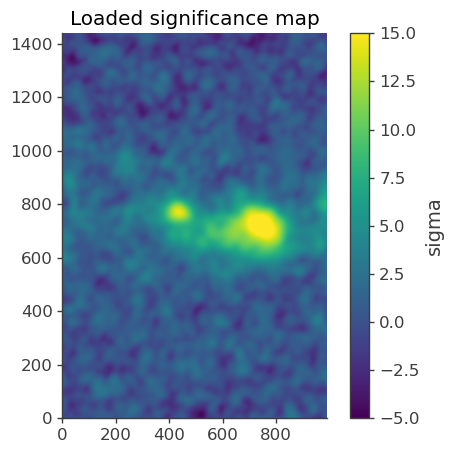

In [206]:
seeder.load_hawc_data()
seeder.border_pixels = int(0.5 / seeder.pixel_size)

print(f"Map shape  : {seeder.ynum} x {seeder.xnum}")
print(f"Pixel size : {seeder.pixel_size:.4f} deg")
print(f"Sig range  : [{seeder.array.min():.2f}, {seeder.array.max():.2f}]")

import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(seeder.array, origin='lower', vmin=-5, vmax=15)
plt.colorbar(im, ax=ax, label='sigma')
ax.set_title('Loaded significance map')
plt.show()


## Step 2 — normalise


  Max significance 18.19sigma exceeds threshold 5.0sigma — proceeding with analysis.


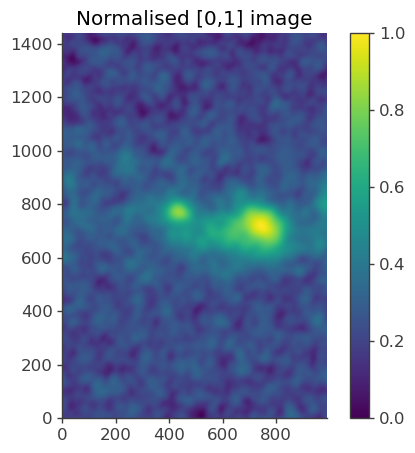

In [207]:
seeder.normalise_image(seeder.array)

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(seeder.norm_image, origin='lower', vmin=0, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_title('Normalised [0,1] image')
plt.show()


## Step 3 — DoG blob detection across smear radii

Runs `blob_detection()` as defined by the class (radii `SMEAR_RADII = [0.25, 0.3, 0.4, 0.5]`, 5 sigma per-radius filter, 5.1 sigma final filter). This is the slow step.


Processing radius 0.25°:   0%|          | 0/4 [00:00<?, ?it/s]

Number of pixels corresponding to 0.25 smear radius = 45.00
Estimated background RMS: 0.03696843411408073
Raw blobs — point source: 3, extended: 1


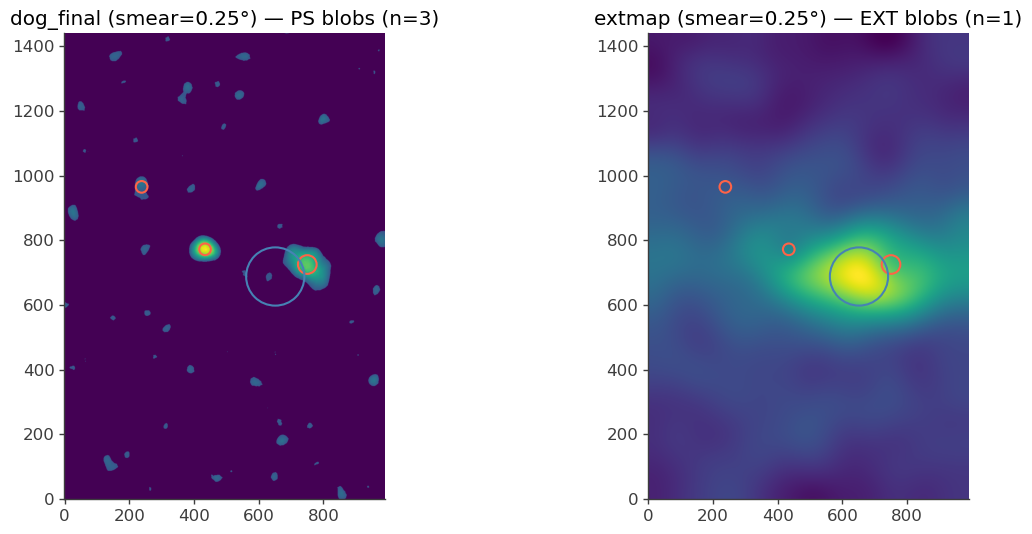

Processing radius 0.30°:  25%|██▌       | 1/4 [00:04<00:13,  4.58s/it]

Blob accepted: max pixel=14.653, Coords (288.67 deg, 11.82 deg), Radius=18.00, Angular Radius=0.100
Blob accepted: max pixel=18.191, Coords (288.08 deg, 10.14 deg), Radius=28.80, Angular Radius=0.160
Blob accepted: max pixel=4.821, Coords (288.22 deg, 13.28 deg), Radius=18.00, Angular Radius=0.100
Blob accepted: max pixel=17.529, Coords (288.53 deg, 10.54 deg), Radius=90.00, Angular Radius=0.500
Sources after 5$\sigma$ filtering: 4
Number of pixels corresponding to 0.30 smear radius = 54.00
Estimated background RMS: 0.0399358776175511
Raw blobs — point source: 3, extended: 1


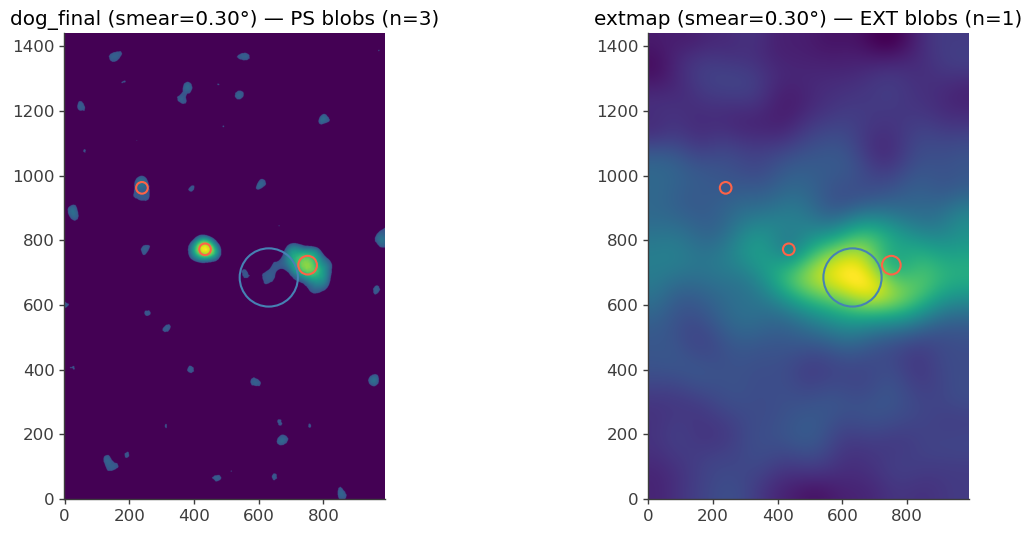

Processing radius 0.40°:  50%|█████     | 2/4 [00:09<00:09,  4.63s/it]

Blob accepted: max pixel=14.653, Coords (288.67 deg, 11.82 deg), Radius=18.00, Angular Radius=0.100
Blob accepted: max pixel=18.191, Coords (288.09 deg, 10.13 deg), Radius=28.80, Angular Radius=0.160
Blob accepted: max pixel=4.799, Coords (288.23 deg, 13.27 deg), Radius=18.00, Angular Radius=0.100
Blob accepted: max pixel=15.673, Coords (288.59 deg, 10.63 deg), Radius=90.00, Angular Radius=0.500
Sources after 5$\sigma$ filtering: 4
Number of pixels corresponding to 0.40 smear radius = 72.00
Estimated background RMS: 0.04419431735462041
Raw blobs — point source: 3, extended: 1


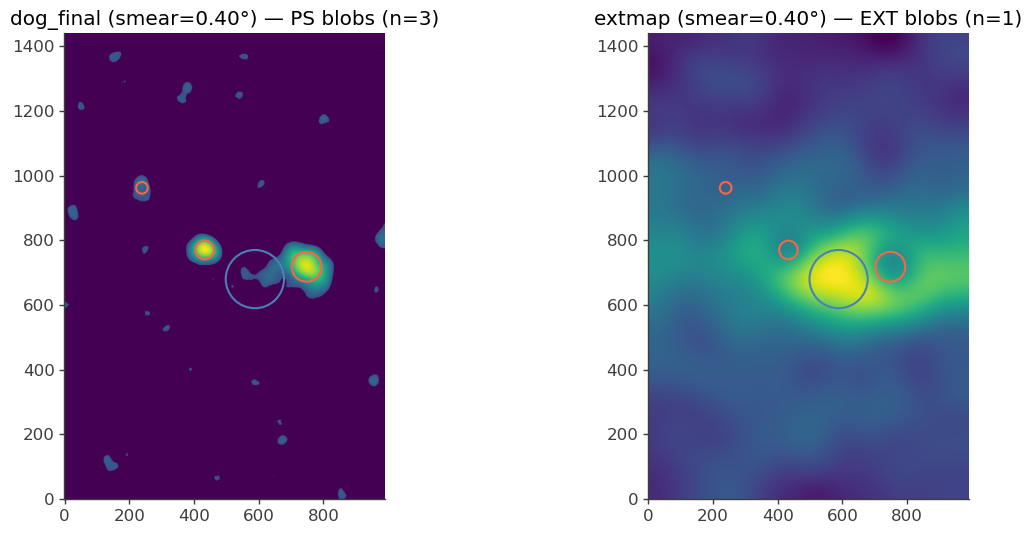

Processing radius 0.50°:  75%|███████▌  | 3/4 [00:13<00:04,  4.68s/it]

Blob accepted: max pixel=14.653, Coords (288.69 deg, 11.82 deg), Radius=28.80, Angular Radius=0.160
Blob accepted: max pixel=18.191, Coords (288.12 deg, 10.14 deg), Radius=46.08, Angular Radius=0.256
Blob accepted: max pixel=4.799, Coords (288.23 deg, 13.27 deg), Radius=18.00, Angular Radius=0.100
Blob accepted: max pixel=12.384, Coords (288.73 deg, 10.82 deg), Radius=90.00, Angular Radius=0.500
Sources after 5$\sigma$ filtering: 4
Number of pixels corresponding to 0.50 smear radius = 90.00
Estimated background RMS: 0.04685153118868876
Raw blobs — point source: 3, extended: 1


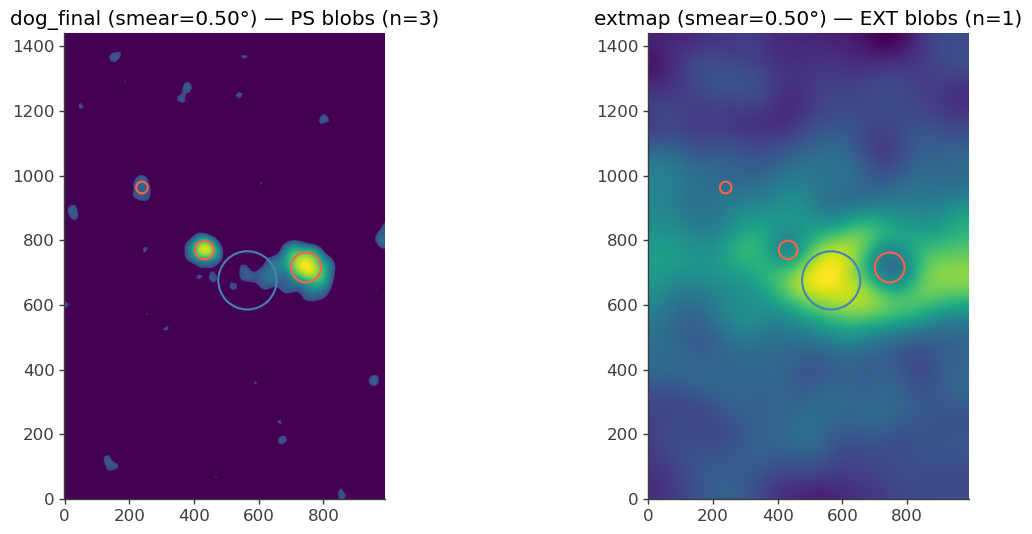

Blob accepted: max pixel=18.191, Coords (288.14 deg, 10.14 deg), Radius=46.08, Angular Radius=0.256
Blob accepted: max pixel=14.653, Coords (288.69 deg, 11.82 deg), Radius=28.80, Angular Radius=0.160
Blob accepted: max pixel=4.821, Coords (288.23 deg, 13.27 deg), Radius=18.00, Angular Radius=0.100
Blob accepted: max pixel=11.785, Coords (288.81 deg, 10.93 deg), Radius=90.00, Angular Radius=0.500
Sources after 5$\sigma$ filtering: 4
Blob accepted: max pixel=14.653, Coords (288.68 deg, 11.82 deg), Radius=23.39, Angular Radius=0.130
Blob accepted: max pixel=18.191, Coords (288.11 deg, 10.14 deg), Radius=37.48, Angular Radius=0.208
Blob accepted: max pixel=13.796, Coords (288.65 deg, 10.71 deg), Radius=90.00, Angular Radius=0.500
  PS  after all cuts:    2
  EXT after all cuts:    1


In [208]:
seeder.blob_detection(seeder.norm_image)


final_ps_blobs : 2
final_ext_blobs: 1


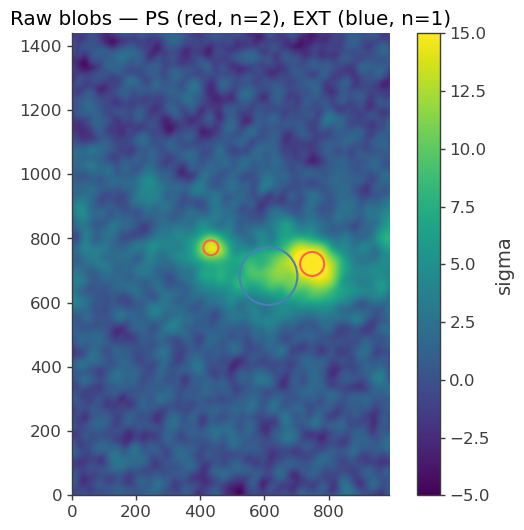

In [209]:
print(f"\nfinal_ps_blobs : {len(seeder.final_ps_blobs)}")
print(f"final_ext_blobs: {len(seeder.final_ext_blobs)}")

fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(seeder.array, origin='lower', vmin=-5, vmax=15)
plt.colorbar(im, ax=ax, label='sigma')
for b in seeder.final_ps_blobs:
    y, x, r = b
    ax.add_patch(plt.Circle((x, y), r, fill=False, edgecolor='tomato', linewidth=1.5),)
for b in seeder.final_ext_blobs:
    y, x, r = b
    ax.add_patch(plt.Circle((x, y), r, fill=False, edgecolor='steelblue', linewidth=1.5))
ax.set_title(f"Raw blobs — PS (red, n={len(seeder.final_ps_blobs)}), "
             f"EXT (blue, n={len(seeder.final_ext_blobs)})")
plt.show()

## Step 4 — group PS blobs under their parent EXT blob

This is `group_blobs()` + `blob_filters()` as the class defines them (circle-overlap grouping with a 0.1 area-fraction gate, then geometric sep/TS-difference tagging). To compare against the connectivity + saddle-height deblending from the earlier notebook instead, run the commented block below in place of these two calls.


In [210]:
seeder.group_blobs()
seeder.blob_filters()

# ── Alternative: connectivity + saddle-height deblending ───────────────────
# candidate_peaks = [(b[0], b[1]) for b in seeder.final_ps_blobs] + \
#                   [(b[0], b[1]) for b in seeder.final_ext_blobs]
# min_distance_px = max(int(0.1 / seeder.pixel_size), 1)
# deblended = deblend_map(
#     seeder.array, threshold=5.05,
#     min_area=int(np.pi * min_distance_px**2),
#     min_dts=16.0, min_distance=min_distance_px,
#     candidate_peaks=candidate_peaks,
# )
# print(f"{len(deblended)} deblended sources "
#       f"({sum(s['n_merged']>1 for s in deblended)} absorbed >1 peak)")
# seeder.ps_filtered_group  = [(s['y'], s['x'], min_distance_px) for s in deblended]
# seeder.ext_filtered_group = []
# seeder.ps_removed_group, seeder.ext_removed_group = [], []


Intensity Fraction of pixels greater than 5 sigma detection threshold = 77.0%
  Kept   — PS: 2  EXT: 1
  Removed— PS: 0  EXT: 0
  PS dedup: 2 → 2 kept, 0 removed
Final — PS kept: 2  EXT kept: 1
        PS removed: 0  EXT removed: 0


([(np.float64(720.4823390072664),
   np.float64(748.7415518422256),
   np.float64(37.48145939499838)),
  (np.float64(771.0012332100312),
   np.float64(433.25118783135764),
   np.float64(23.39334066583131))],
 [(np.float64(682.7842332374761),
   np.float64(612.7462770843575),
   np.float64(89.99999999999999))],
 [],
 [])

## Step 5 — filtered result and seed YAML


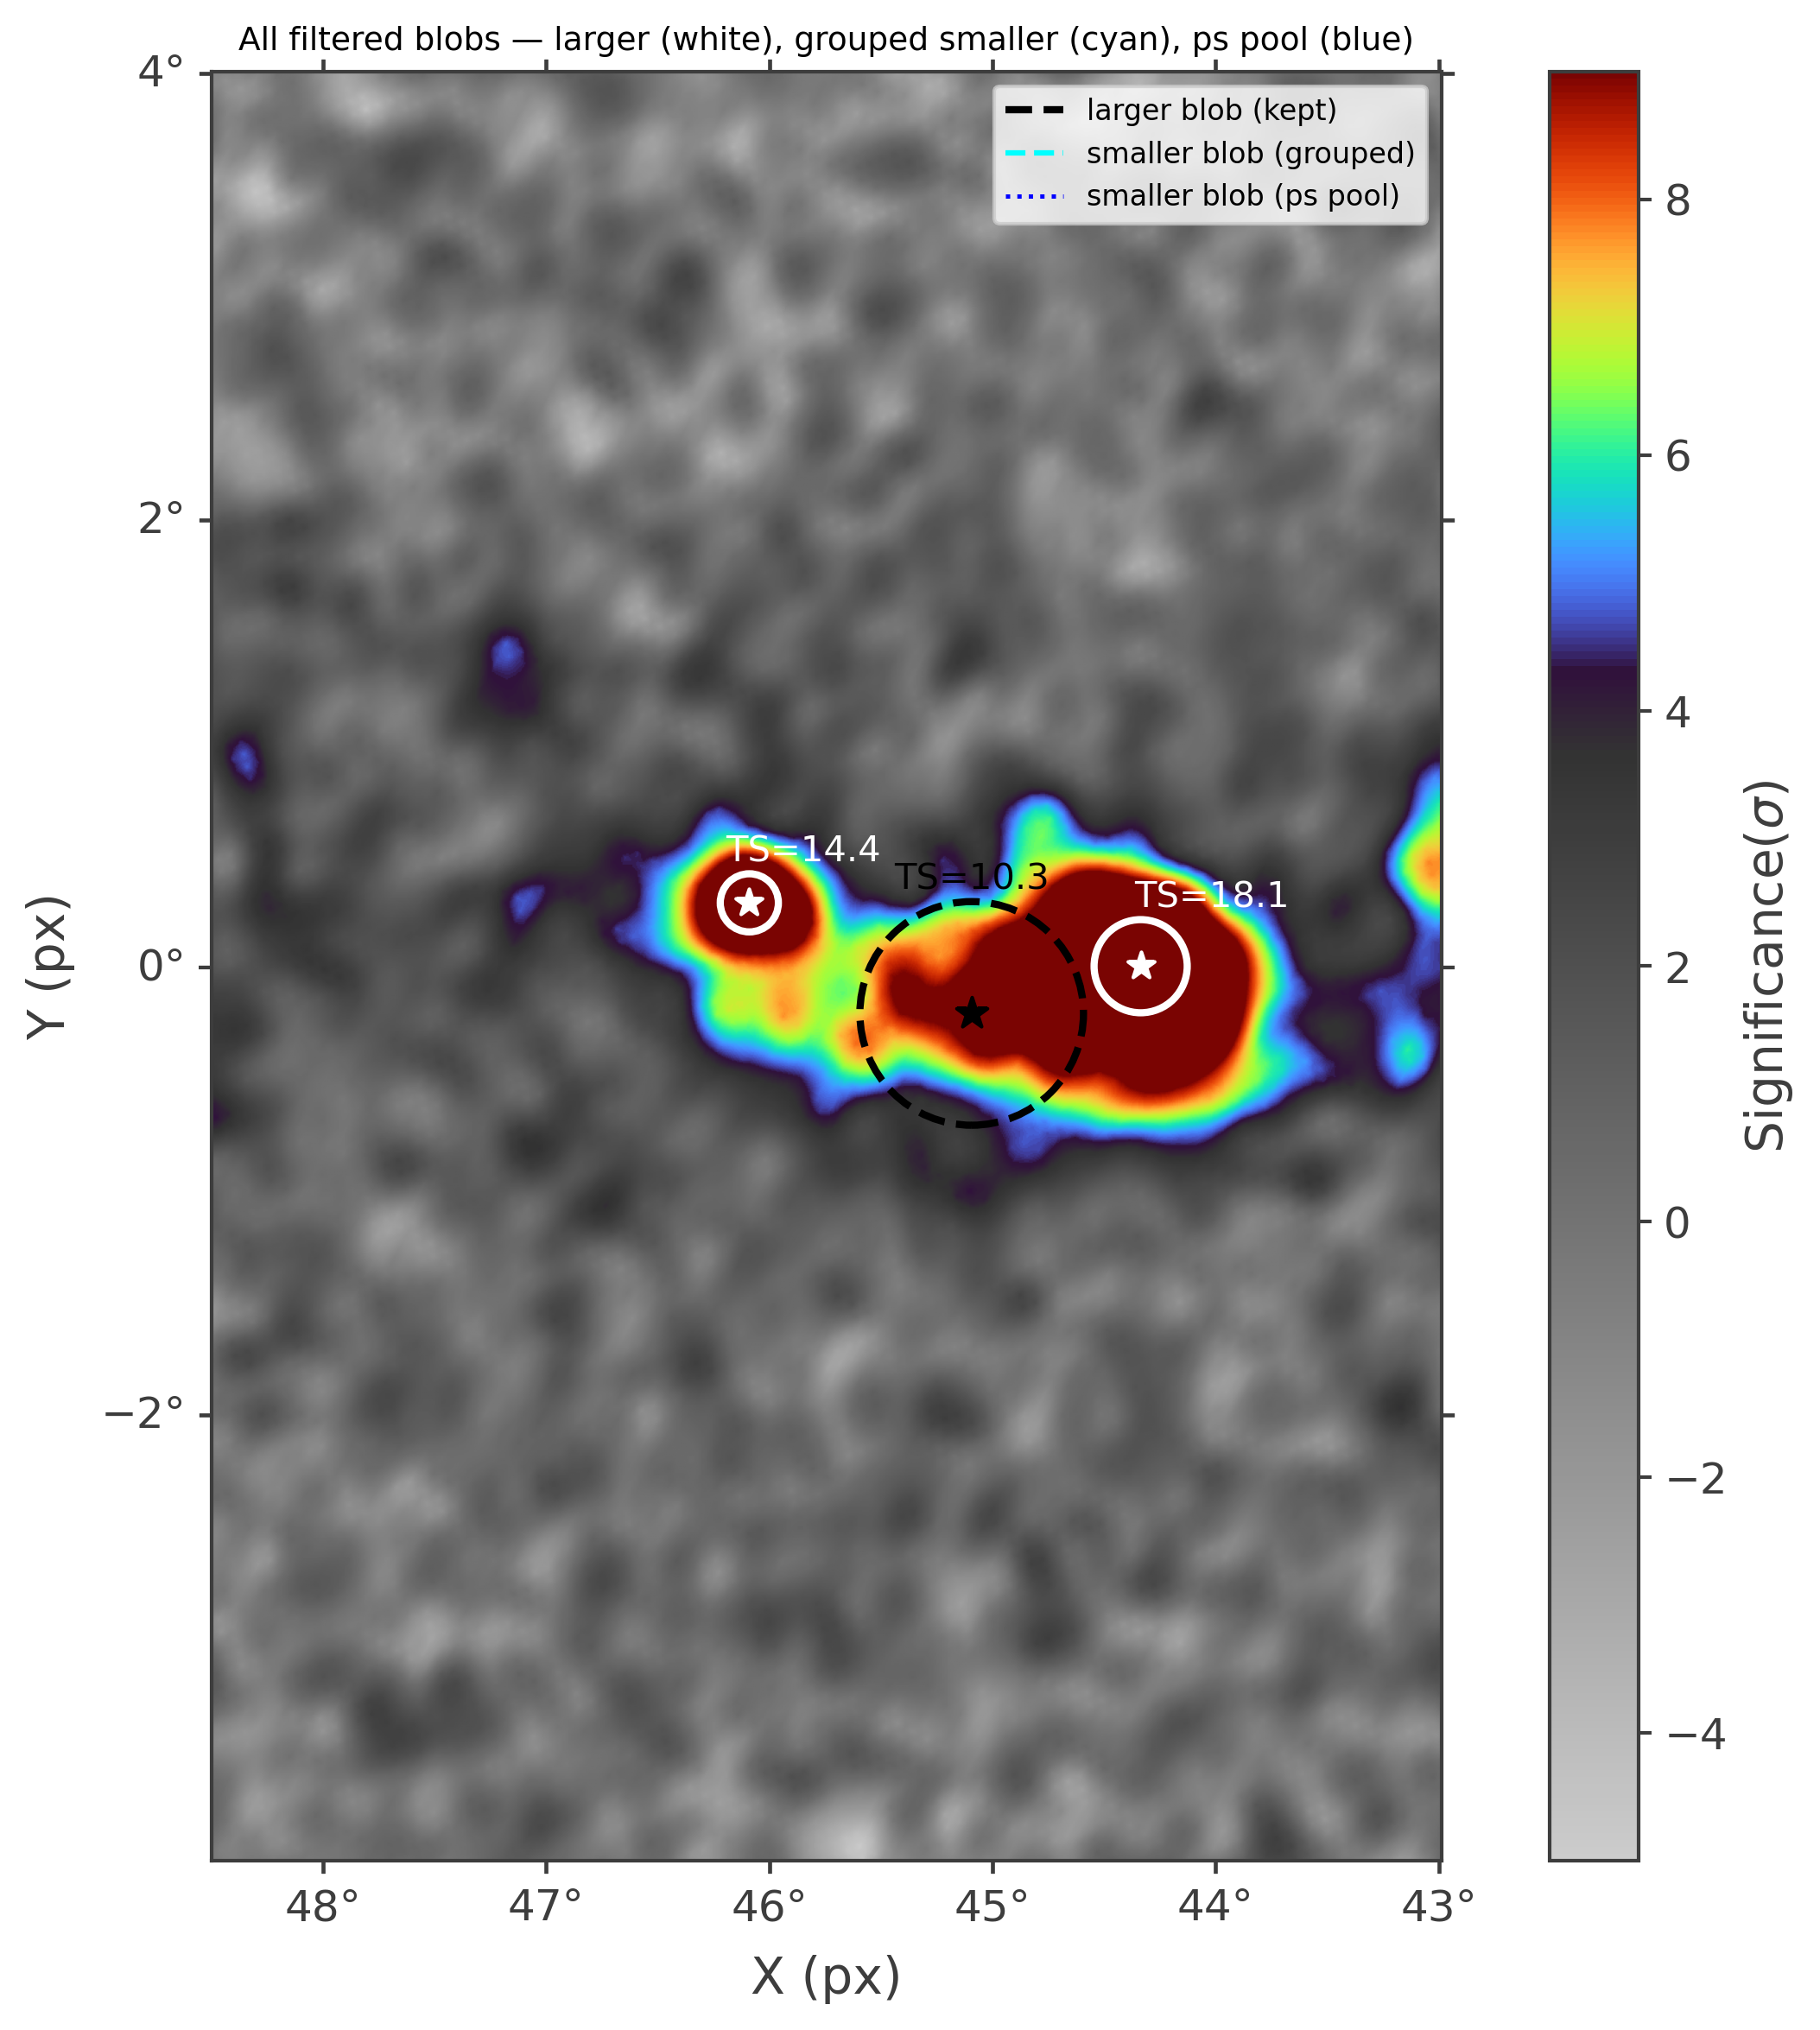

In [211]:
seeder.plot_filtering_results(title='FilteredBlobs_Interactive')
show('FilteredBlobs_Interactive')


In [212]:
seeder.save_model()
print(seeder.filtered_df)


Converting blob at (x=612.7462770843575, y=682.7842332374761, r=90.00 pixels) to coord (RA=288.652°, Dec=10.710°) with radius 0.50°
Converting blob at (x=748.7415518422256, y=720.4823390072664, r=37.48 pixels) to coord (RA=288.107°, Dec=10.138°) with radius 0.21°
Converting blob at (x=433.25118783135764, y=771.0012332100312, r=23.39 pixels) to coord (RA=288.682°, Dec=11.821°) with radius 0.13°
[INFO] Found 3 sources, 3 within original ROI
[INFO] Results saved to: ./drips_interactive_output/filtered_sources.yaml
[INFO] Results saved to: ./drips_interactive_output/filtered_sources.yaml
    Name          ra        dec       ext  Circle Radius  Sigma Radius
0  Drip0  288.106544  10.138101  0.208230       0.208230      0.137428
1  Drip1  288.681725  11.820963  0.129963       0.129963      0.085773
2  Drip2  288.651602  10.710231  0.500000       0.500000      0.329991


Plotting source Drip0 at (RA=288.107°, Dec=10.138°) with radius 0.21°
Plotting source Drip1 at (RA=288.682°, Dec=11.821°) with radius 0.13°
Plotting source Drip2 at (RA=288.652°, Dec=10.710°) with radius 0.50°


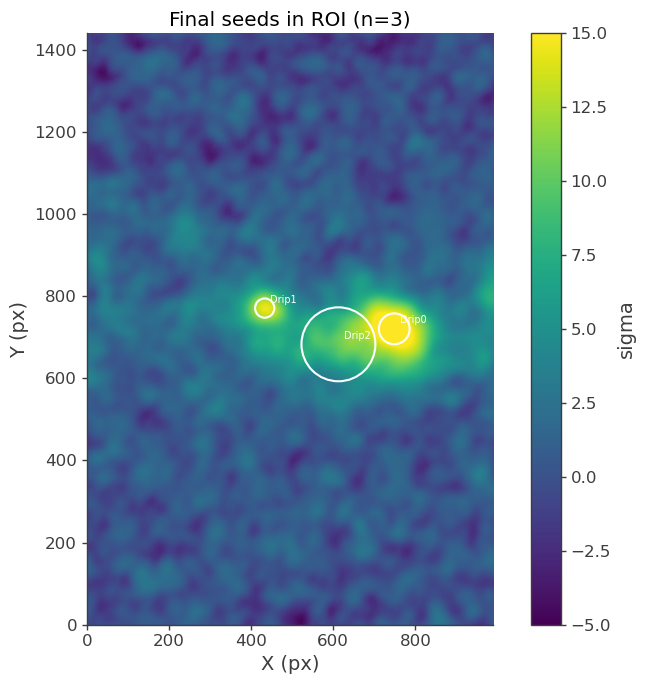

In [213]:
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
import astropy.wcs.utils as astropy_utils

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(seeder.array, origin='lower', vmin=-5, vmax=15, cmap='viridis')
plt.colorbar(im, ax=ax, label='sigma')

for _, row in seeder.filtered_df.iterrows():
    coord = SkyCoord(ra=row['ra']*u.deg, dec=row['dec']*u.deg, frame='icrs')
    print(f"Plotting source {row['Name']} at (RA={coord.ra.deg:.3f}°, Dec={coord.dec.deg:.3f}°) with radius {row['Circle Radius']:.2f}°")
    x, y = astropy_utils.skycoord_to_pixel(coord, seeder.wcs)
    r_px = row['Circle Radius'] / seeder.pixel_size

    ax.add_patch(plt.Circle((x, y), r_px, fill=False, edgecolor='white', linewidth=1.5))
    ax.annotate(row['Name'], (x, y), color='white', fontsize=7,
                xytext=(4, 4), textcoords='offset points')

ax.set_xlim(0, seeder.xnum)
ax.set_ylim(0, seeder.ynum)
ax.set_title(f"Final seeds in ROI (n={len(seeder.filtered_df)})")
ax.set_xlabel('X (px)'); ax.set_ylabel('Y (px)')
plt.tight_layout()
plt.show()